In [1]:
import pandas as pd

orders = pd.read_csv("data/orders.csv")
order_items = pd.read_csv("data/order_items.csv")
customers = pd.read_csv("data/customers.csv")
products = pd.read_csv("data/products.csv")

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)

Orders: (100000, 16)
Order Items: (254331, 9)
Customers: (25000, 18)
Products: (550, 14)


In [2]:
print("ORDERS")
print(orders.columns.tolist())
print("\nORDER ITEMS")
print(order_items.columns.tolist())
print("\nCUSTOMERS")
print(customers.columns.tolist())
print("\nPRODUCTS")
print(products.columns.tolist())

ORDERS
['order_id', 'customer_id', 'order_date', 'order_time', 'order_status', 'shipping_method', 'delivery_city', 'delivery_state', 'coupon_code', 'discount_percentage', 'marketing_channel', 'subtotal', 'shipping_fee', 'tax_amount', 'final_amount', 'campaign_id']

ORDER ITEMS
['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'discount_percentage', 'item_revenue', 'item_cost', 'profit']

CUSTOMERS
['customer_id', 'customer_signup_date', 'gender', 'age', 'age_group', 'state', 'city', 'pincode_prefix', 'customer_segment', 'preferred_device', 'preferred_payment_method', 'acquisition_channel', 'total_orders', 'total_spend', 'last_order_date', 'average_order_value', 'customer_status', 'loyalty_tier']

PRODUCTS
['product_id', 'product_name', 'category', 'subcategory', 'brand', 'price', 'cost_price', 'discount_range', 'rating_average', 'rating_count', 'stock_quantity', 'product_launch_date', 'product_type', 'return_rate_baseline']


In [3]:
orders.head()

,order_id,customer_id,order_date,order_time,order_status,shipping_method,delivery_city,delivery_state,coupon_code,discount_percentage,marketing_channel,subtotal,shipping_fee,tax_amount,final_amount,campaign_id
0,ORD1000000,CUST103868,2025-08-16,22:35:23,Failed,Next-Day,Mumbai,Maharashtra,FEST20,5.0,SMS Marketing,14439.9,0.0,722.0,15161.9,NaN
1,ORD1000001,CUST118472,2023-02-11,18:51:17,Delivered,Economy/Surface,Thiruvananthapuram,Kerala,FEST20,15.0,Social Media - Facebook,4760.0,0.0,238.0,4998.0,CAMP1008
2,ORD1000002,CUST120793,2024-12-14,11:08:38,Delivered,Economy/Surface,Nagpur,Maharashtra,APP5,30.0,Social Media - Instagram,826.0,0.0,41.3,867.3,CAMP1101
3,ORD1000003,CUST109166,2025-11-23,09:32:24,Failed,Express,Kochi,Kerala,BIGBILLION,5.0,Direct/App,25878.0,0.0,1293.9,27171.9,NaN
4,ORD1000004,CUST119895,2025-07-27,20:35:25,Cancelled,Standard,Jaipur,Rajasthan,SAVE15,30.0,Organic Search,3450.0,0.0,172.5,3622.5,NaN


In [4]:
print("ORDERS")
orders.info()

print("\nORDER ITEMS")
order_items.info()

print("\nCUSTOMERS")
customers.info()

print("\nPRODUCTS")
products.info()

ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             100000 non-null  str    
 1   customer_id          100000 non-null  str    
 2   order_date           100000 non-null  str    
 3   order_time           100000 non-null  str    
 4   order_status         100000 non-null  str    
 5   shipping_method      100000 non-null  str    
 6   delivery_city        100000 non-null  str    
 7   delivery_state       100000 non-null  str    
 8   coupon_code          66289 non-null   str    
 9   discount_percentage  100000 non-null  float64
 10  marketing_channel    100000 non-null  str    
 11  subtotal             100000 non-null  float64
 12  shipping_fee         100000 non-null  float64
 13  tax_amount           100000 non-null  float64
 14  final_amount         100000 non-null  float64
 15  campaign_id          1

In [5]:
orders.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,100000,100000,ORD1000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,22820,CUST107174,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,100000,1096,2025-12-31,707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_time,100000,51489,19:07:28,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,100000,5,Delivered,80679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_method,100000,5,Standard,44852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_city,100000,31,Mumbai,4803,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_state,100000,15,Maharashtra,14196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coupon_code,66289,8,WELCOME10,8392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_percentage,100000.0,NaN,NaN,NaN,11.98425,10.687991,0.0,0.0,10.0,20.0,30.0


In [6]:
print("Missing values in ORDERS:")
print(orders.isnull().sum())

print("\nDuplicate rows in ORDERS:")
print(orders.duplicated().sum())

print("\nDuplicate Order IDs:")
print(orders["order_id"].duplicated().sum())

Missing values in ORDERS:
order_id                   0
customer_id                0
order_date                 0
order_time                 0
order_status               0
shipping_method            0
delivery_city              0
delivery_state             0
coupon_code            33711
discount_percentage        0
marketing_channel          0
subtotal                   0
shipping_fee               0
tax_amount                 0
final_amount               0
campaign_id            82821
dtype: int64

Duplicate rows in ORDERS:
0

Duplicate Order IDs:
0


In [7]:
for name, df in {
    "ORDER ITEMS": order_items,
    "CUSTOMERS": customers,
    "PRODUCTS": products
}.items():

    print(name)

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

ORDER ITEMS

Missing values:
order_item_id          0
order_id               0
product_id             0
quantity               0
unit_price             0
discount_percentage    0
item_revenue           0
item_cost              0
profit                 0
dtype: int64

Duplicate rows: 0
CUSTOMERS

Missing values:
customer_id                    0
customer_signup_date           0
gender                         0
age                          250
age_group                      0
state                          0
city                           0
pincode_prefix                 0
customer_segment               0
preferred_device             125
preferred_payment_method       0
acquisition_channel            0
total_orders                   0
total_spend                    0
last_order_date             2300
average_order_value            0
customer_status                0
loyalty_tier                   0
dtype: int64

Duplicate rows: 0
PRODUCTS

Missing values:
product_id              0
product_n

In [8]:
print("CUSTOMERS MISSING:")
print(customers.isnull().sum()[customers.isnull().sum() > 0])

print("\nPRODUCTS MISSING:")
print(products.isnull().sum()[products.isnull().sum() > 0])

CUSTOMERS MISSING:
age                  250
preferred_device     125
last_order_date     2300
dtype: int64

PRODUCTS MISSING:
rating_average    4
dtype: int64


In [9]:
# Orders
orders["coupon_code"] = orders["coupon_code"].fillna("No Coupon")
orders["campaign_id"] = orders["campaign_id"].fillna("No Campaign")

# Customers
customers["age"] = customers["age"].fillna(customers["age"].median())
customers["preferred_device"] = customers["preferred_device"].fillna("Unknown")

# Products
products["rating_average"] = products["rating_average"].fillna(
    products["rating_average"].median()
)

In [10]:
print(orders.isnull().sum().sum())
print(customers.isnull().sum().sum())
print(products.isnull().sum().sum())

0
2300
0


In [11]:
customer_order_check = customers["customer_id"].isin(orders["customer_id"])

print("Customers with orders:", customer_order_check.sum())
print("Customers without orders:", (~customer_order_check).sum())

Customers with orders: 22820
Customers without orders: 2180


In [12]:
missing_last_order = customers["last_order_date"].isna()

print("Missing last_order_date:", missing_last_order.sum())
print(
    "Missing date + no orders:",
    (
        missing_last_order
        & ~customers["customer_id"].isin(orders["customer_id"])
    ).sum()
)

Missing last_order_date: 2300
Missing date + no orders: 2180


In [13]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
customers["customer_signup_date"] = pd.to_datetime(
    customers["customer_signup_date"]
)
customers["last_order_date"] = pd.to_datetime(
    customers["last_order_date"]
)

In [14]:
last_orders = (
    orders.groupby("customer_id")["order_date"]
    .max()
)

customers["last_order_date"] = customers["customer_id"].map(
    last_orders
).fillna(customers["last_order_date"])

In [15]:
print("Missing last_order_date:",
      customers["last_order_date"].isna().sum())

Missing last_order_date: 2180


In [16]:
orders["year"] = orders["order_date"].dt.year
orders["month"] = orders["order_date"].dt.month
orders["month_name"] = orders["order_date"].dt.month_name()
orders["quarter"] = orders["order_date"].dt.quarter
orders["day_of_week"] = orders["order_date"].dt.day_name()

In [17]:
orders[
    ["order_date", "year", "month", "month_name", "quarter", "day_of_week"]
].head()

,order_date,year,month,month_name,quarter,day_of_week
0,2025-08-16,2025,8,August,3,Saturday
1,2023-02-11,2023,2,February,1,Saturday
2,2024-12-14,2024,12,December,4,Saturday
3,2025-11-23,2025,11,November,4,Sunday
4,2025-07-27,2025,7,July,3,Sunday


In [18]:
order_items[
    ["quantity", "unit_price", "discount_percentage",
     "item_revenue", "item_cost", "profit"]
].describe()

,quantity,unit_price,discount_percentage,item_revenue,item_cost,profit
count,254331.000000,254331.000000,254331.000000,254331.000000,254331.000000,254331.000000
mean,2.302669,4796.386992,12.899855,9632.718679,8856.980185,775.738494
std,1.138847,11229.239979,10.741200,25845.808896,25305.466331,3639.700982
min,1.000000,50.000000,0.000000,33.500000,34.120000,-108249.360000
25%,1.000000,570.000000,3.000000,884.000000,713.760000,63.060000
50%,2.000000,1210.000000,11.500000,2245.800000,1772.400000,315.290000
75%,3.000000,3150.000000,21.500000,6289.500000,5141.920000,982.410000
max,8.000000,76020.000000,33.000000,577752.000000,551799.680000,75057.360000


In [19]:
order_items["calculated_revenue"] = (
    order_items["quantity"]
    * order_items["unit_price"]
    * (1 - order_items["discount_percentage"] / 100)
)

print(
    (order_items["item_revenue"] - order_items["calculated_revenue"])
    .abs()
    .describe()
)

count    2.543310e+05
mean     1.153120e-13
std      9.560638e-13
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.820766e-11
dtype: float64


In [20]:
order_items[
    ["quantity", "unit_price", "discount_percentage",
     "item_revenue", "calculated_revenue"]
].head(10)

,quantity,unit_price,discount_percentage,item_revenue,calculated_revenue
0,4,150.0,6.5,561.0,561.0
1,1,1150.0,5.0,1092.5,1092.5
2,2,960.0,8.0,1766.4,1766.4
3,4,920.0,5.0,3496.0,3496.0
4,3,2640.0,5.0,7524.0,7524.0
5,5,920.0,15.0,3910.0,3910.0
6,2,500.0,15.0,850.0,850.0
7,2,590.0,30.0,826.0,826.0
8,2,12300.0,5.0,23370.0,23370.0
9,1,2640.0,5.0,2508.0,2508.0


In [21]:
sales = order_items.merge(
    orders,
    on="order_id",
    how="left"
)

print("Sales shape:", sales.shape)
print("\nColumns:")
print(sales.columns.tolist())

Sales shape: (254331, 30)

Columns:
['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'discount_percentage_x', 'item_revenue', 'item_cost', 'profit', 'calculated_revenue', 'customer_id', 'order_date', 'order_time', 'order_status', 'shipping_method', 'delivery_city', 'delivery_state', 'coupon_code', 'discount_percentage_y', 'marketing_channel', 'subtotal', 'shipping_fee', 'tax_amount', 'final_amount', 'campaign_id', 'year', 'month', 'month_name', 'quarter', 'day_of_week']


In [22]:
sales.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_percentage_x,item_revenue,item_cost,profit,calculated_revenue,...,subtotal,shipping_fee,tax_amount,final_amount,campaign_id,year,month,month_name,quarter,day_of_week
0,OI10000000,ORD1000000,PROD10347,4,150.0,6.5,561.0,515.92,45.08,561.0,...,14439.9,0.0,722.0,15161.9,No Campaign,2025,8,August,3,Saturday
1,OI10000001,ORD1000000,PROD10510,1,1150.0,5.0,1092.5,752.18,340.32,1092.5,...,14439.9,0.0,722.0,15161.9,No Campaign,2025,8,August,3,Saturday
2,OI10000002,ORD1000000,PROD10305,2,960.0,8.0,1766.4,1217.66,548.74,1766.4,...,14439.9,0.0,722.0,15161.9,No Campaign,2025,8,August,3,Saturday
3,OI10000003,ORD1000000,PROD10092,4,920.0,5.0,3496.0,3049.52,446.48,3496.0,...,14439.9,0.0,722.0,15161.9,No Campaign,2025,8,August,3,Saturday
4,OI10000004,ORD1000000,PROD10417,3,2640.0,5.0,7524.0,6847.65,676.35,7524.0,...,14439.9,0.0,722.0,15161.9,No Campaign,2025,8,August,3,Saturday


In [23]:
print("Order items:", len(order_items))
print("Sales rows:", len(sales))

print("\nMissing values after merge:")
print(sales.isnull().sum()[sales.isnull().sum() > 0])

Order items: 254331
Sales rows: 254331

Missing values after merge:
Series([], dtype: int64)


In [24]:
sales = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

print("Sales shape:", sales.shape)

print("\nMissing values after customer merge:")
print(sales.isnull().sum()[sales.isnull().sum() > 0])

Sales shape: (254331, 47)

Missing values after customer merge:
Series([], dtype: int64)


In [25]:
sales.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_percentage_x,item_revenue,item_cost,profit,calculated_revenue,...,customer_segment,preferred_device,preferred_payment_method,acquisition_channel,total_orders,total_spend,last_order_date,average_order_value,customer_status,loyalty_tier
0,OI10000000,ORD1000000,PROD10347,4,150.0,6.5,561.0,515.92,45.08,561.0,...,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum
1,OI10000001,ORD1000000,PROD10510,1,1150.0,5.0,1092.5,752.18,340.32,1092.5,...,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum
2,OI10000002,ORD1000000,PROD10305,2,960.0,8.0,1766.4,1217.66,548.74,1766.4,...,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum
3,OI10000003,ORD1000000,PROD10092,4,920.0,5.0,3496.0,3049.52,446.48,3496.0,...,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum
4,OI10000004,ORD1000000,PROD10417,3,2640.0,5.0,7524.0,6847.65,676.35,7524.0,...,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum


In [26]:
sales = sales.merge(
    products,
    on="product_id",
    how="left"
)

print("Final sales shape:", sales.shape)

print("\nMissing values after product merge:")
print(sales.isnull().sum()[sales.isnull().sum() > 0])

Final sales shape: (254331, 60)

Missing values after product merge:
Series([], dtype: int64)


In [27]:
sales.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_percentage_x,item_revenue,item_cost,profit,calculated_revenue,...,brand,price,cost_price,discount_range,rating_average,rating_count,stock_quantity,product_launch_date,product_type,return_rate_baseline
0,OI10000000,ORD1000000,PROD10347,4,150.0,6.5,561.0,515.92,45.08,561.0,...,"Murthy,",150.0,128.98,30-45%,3.9,118,2078,2023-01-23,Standard,0.0111
1,OI10000001,ORD1000000,PROD10510,1,1150.0,5.0,1092.5,752.18,340.32,1092.5,...,"Iyer,",1150.0,752.18,20-35%,3.7,1107,2987,2024-09-09,Budget,0.0316
2,OI10000002,ORD1000000,PROD10305,2,960.0,8.0,1766.4,1217.66,548.74,1766.4,...,Patla-Gaba,960.0,608.83,5-20%,4.3,156,2026,2023-03-29,Standard,0.0971
3,OI10000003,ORD1000000,PROD10092,4,920.0,5.0,3496.0,3049.52,446.48,3496.0,...,"Mittal,",920.0,762.38,0-15%,3.3,361,2994,2024-12-19,Standard,0.0122
4,OI10000004,ORD1000000,PROD10417,3,2640.0,5.0,7524.0,6847.65,676.35,7524.0,...,Goda,2640.0,2282.55,20-35%,3.8,1326,684,2023-10-30,Standard,0.0838


In [28]:
total_revenue = sales["item_revenue"].sum()
total_profit = sales["profit"].sum()
total_orders = sales["order_id"].nunique()
total_customers = sales["customer_id"].nunique()
total_items_sold = sales["quantity"].sum()

average_order_value = total_revenue / total_orders

print("Total Revenue: ₹", round(total_revenue, 2))
print("Total Profit: ₹", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Items Sold:", total_items_sold)
print("Average Order Value: ₹", round(average_order_value, 2))

Total Revenue: ₹ 2449898974.35
Total Profit: ₹ 197294347.02
Total Orders: 100000
Total Customers: 22820
Total Items Sold: 585640
Average Order Value: ₹ 24498.99


In [29]:
monthly_sales = (
    sales.groupby(sales["order_date"].dt.to_period("M"))
    .agg(
        revenue=("item_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales["order_date"] = monthly_sales["order_date"].dt.to_timestamp()

monthly_sales.head()

,order_date,revenue,profit,orders
0,2023-01-01,10180025.35,811318.40,398
1,2023-02-01,23372276.35,2129457.68,942
2,2023-03-01,44064286.65,2920436.44,1692
3,2023-04-01,53378512.40,3633466.97,2198
4,2023-05-01,60518956.00,4613663.78,2411


Matplotlib is building the font cache; this may take a moment.


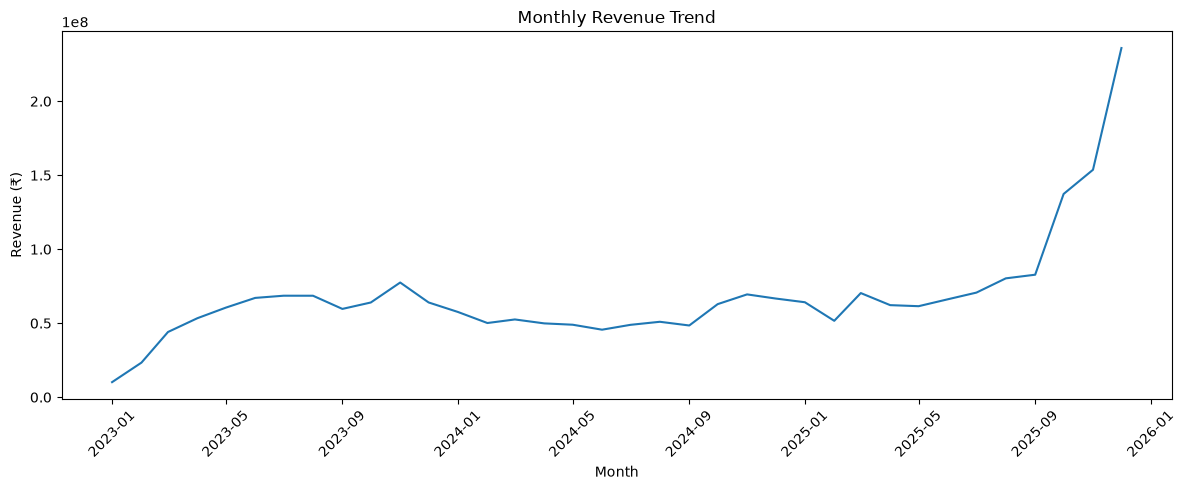

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
highest_month = monthly_sales.loc[
    monthly_sales["revenue"].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales["revenue"].idxmin()
]

print("Highest Revenue Month:")
print(highest_month)

print("\nLowest Revenue Month:")
print(lowest_month)

Highest Revenue Month:
order_date    2025-12-01 00:00:00
revenue              235942347.65
profit                18645976.06
orders                       9590
Name: 35, dtype: object

Lowest Revenue Month:
order_date    2023-01-01 00:00:00
revenue               10180025.35
profit                   811318.4
orders                        398
Name: 0, dtype: object


In [32]:
yearly_sales = (
    sales.groupby("year")
    .agg(
        revenue=("item_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

yearly_sales

,year,revenue,profit,orders
0,2023,6.609513e+08,51981200.01,26750
1,2024,6.521271e+08,51941081.98,26730
2,2025,1.136821e+09,93372065.03,46520


In [33]:
category_sales = (
    sales.groupby("category")
    .agg(
        revenue=("item_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_sales

,revenue,profit,orders,quantity
category,,,,
Electronics,1.223619e+09,8450905.95,23018,59068
Appliances,4.052333e+08,15743436.40,14680,35842
Home & Kitchen,1.580755e+08,28392024.89,23589,60205
Furniture,1.470115e+08,14348527.85,3506,8118
Fashion,1.393936e+08,46192014.22,36022,98750
Footwear,8.260349e+07,24298429.50,13313,32501
Bags,5.591211e+07,15984391.42,12267,29948
Health & Wellness,3.182433e+07,6957754.85,14695,36095
Sports,2.652405e+07,5945316.96,5651,13269


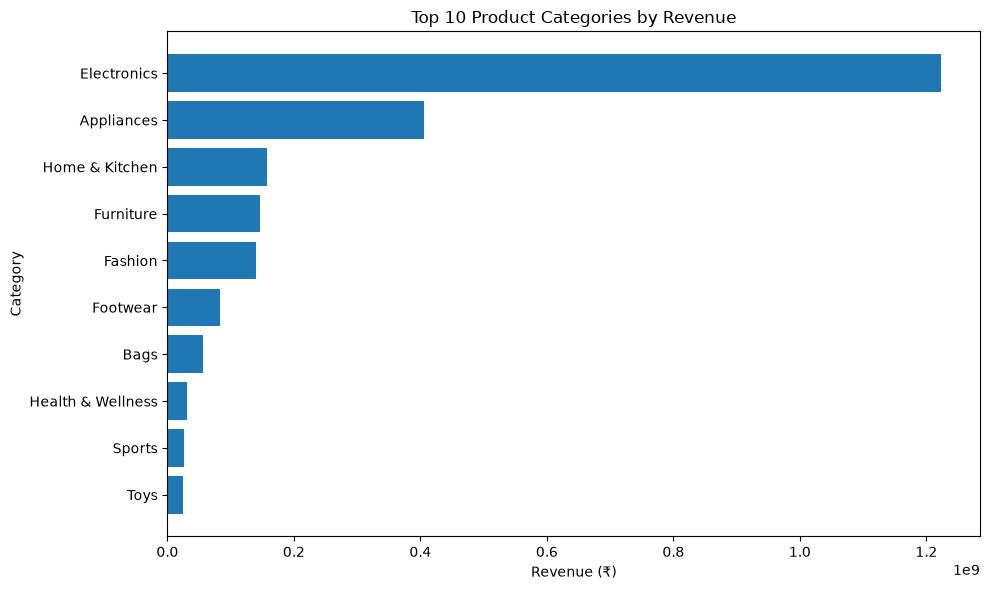

In [34]:
top_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories.index[::-1],
    top_categories["revenue"][::-1]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [35]:
category_profit = (
    sales.groupby("category")
    .agg(
        revenue=("item_revenue", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_profit["profit_margin_%"] = (
    category_profit["profit"]
    / category_profit["revenue"]
    * 100
)

category_profit

,revenue,profit,profit_margin_%
category,,,
Electronics,1.223619e+09,8450905.95,0.690649
Appliances,4.052333e+08,15743436.40,3.885031
Home & Kitchen,1.580755e+08,28392024.89,17.961050
Furniture,1.470115e+08,14348527.85,9.760140
Fashion,1.393936e+08,46192014.22,33.137839
Footwear,8.260349e+07,24298429.50,29.415740
Bags,5.591211e+07,15984391.42,28.588424
Health & Wellness,3.182433e+07,6957754.85,21.863006
Sports,2.652405e+07,5945316.96,22.414816


In [36]:
category_profit.head(10)

,revenue,profit,profit_margin_%
category,,,
Electronics,1.223619e+09,8450905.95,0.690649
Appliances,4.052333e+08,15743436.40,3.885031
Home & Kitchen,1.580755e+08,28392024.89,17.961050
Furniture,1.470115e+08,14348527.85,9.760140
Fashion,1.393936e+08,46192014.22,33.137839
Footwear,8.260349e+07,24298429.50,29.415740
Bags,5.591211e+07,15984391.42,28.588424
Health & Wellness,3.182433e+07,6957754.85,21.863006
Sports,2.652405e+07,5945316.96,22.414816


In [37]:
product_sales = (
    sales.groupby(["product_id", "product_name"])
    .agg(
        revenue=("item_revenue", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
)

product_sales.head(10)

,,revenue,profit,quantity,orders
product_id,product_name,,,,
PROD10246,"Chaudhry, Advanced Smartwatche",5.207029e+08,7972337.41,9048,3828
PROD10203,"Mistry, Basic Large Appliance",1.089752e+08,980618.49,10089,4342
PROD10392,Gandhi-Lanka Ultra Storage & Container,8.141222e+07,16809917.96,11062,4682
PROD10445,Kala-Vaidya Deluxe Laptop,7.203530e+07,-2945852.63,1379,601
PROD10435,"Boase, Ultra Air Conditioner",6.394125e+07,4654790.80,1543,675
PROD10301,"Choudhury, Ultra Laptop",6.177869e+07,-1091.06,2222,945
PROD10236,Shanker-Dhar Signature Headphone,5.708593e+07,3102319.88,8774,3723
PROD10432,Gola Essential Fans & Cooler,5.252888e+07,81513.75,1020,456
PROD10306,Handa Advanced Laptop,5.081709e+07,-1672855.16,761,327


In [38]:
product_sales["profit_margin_%"] = (
    product_sales["profit"] / product_sales["revenue"] * 100
)

product_sales.head(10)

,,revenue,profit,quantity,orders,profit_margin_%
product_id,product_name,,,,,
PROD10246,"Chaudhry, Advanced Smartwatche",5.207029e+08,7972337.41,9048,3828,1.531072
PROD10203,"Mistry, Basic Large Appliance",1.089752e+08,980618.49,10089,4342,0.899855
PROD10392,Gandhi-Lanka Ultra Storage & Container,8.141222e+07,16809917.96,11062,4682,20.647905
PROD10445,Kala-Vaidya Deluxe Laptop,7.203530e+07,-2945852.63,1379,601,-4.089457
PROD10435,"Boase, Ultra Air Conditioner",6.394125e+07,4654790.80,1543,675,7.279793
PROD10301,"Choudhury, Ultra Laptop",6.177869e+07,-1091.06,2222,945,-0.001766
PROD10236,Shanker-Dhar Signature Headphone,5.708593e+07,3102319.88,8774,3723,5.434473
PROD10432,Gola Essential Fans & Cooler,5.252888e+07,81513.75,1020,456,0.155179
PROD10306,Handa Advanced Laptop,5.081709e+07,-1672855.16,761,327,-3.291915


In [39]:
loss_making_products = (
    product_sales[product_sales["profit"] < 0]
    .sort_values("profit")
)

loss_making_products.head(10)

,,revenue,profit,quantity,orders,profit_margin_%
product_id,product_name,,,,,
PROD10445,Kala-Vaidya Deluxe Laptop,72035300.40,-2945852.63,1379,601,-4.089457
PROD10501,"Loke, Deluxe Smartphone",39726851.85,-1970836.74,993,443,-4.960969
PROD10072,"Boase, Essential Tablet",36115101.10,-1790725.46,2688,1133,-4.958384
PROD10421,Mody-Kari Basic Smartphone,49101814.50,-1777992.30,1270,564,-3.621032
PROD10306,Handa Advanced Laptop,50817089.40,-1672855.16,761,327,-3.291915
PROD10152,Behl-Chanda Advanced Camera,19122617.55,-944983.41,5346,2310,-4.941705
PROD10182,Sen Premium Laptop,10853076.85,-540428.00,455,205,-4.979491
PROD10176,Gola Advanced Smartwatche,21418360.20,-483430.62,3178,1376,-2.257085
PROD10063,Dara-Kota Compact Smartwatche,9037739.75,-356014.45,356,155,-3.939198


In [40]:
print("Number of loss-making products:",
      len(loss_making_products))

print(
    "Total loss: ₹",
    round(loss_making_products["profit"].sum(), 2)
)

Number of loss-making products: 33
Total loss: ₹ -13583296.68


In [41]:
customer_sales = (
    sales.groupby("customer_id")
    .agg(
        revenue=("item_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        items=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

customer_sales.head(10)

,revenue,profit,orders,items
customer_id,,,,
CUST117355,1333598.15,47158.22,16,112
CUST117572,1104859.40,74940.28,17,118
CUST124072,1102702.95,90362.33,12,80
CUST108876,1047581.20,17184.81,10,88
CUST112006,1042687.10,51138.60,13,104
CUST102738,1040823.70,31869.84,15,92
CUST119192,1039155.95,68857.58,13,119
CUST121038,990664.95,111721.77,18,163
CUST123291,983411.40,21175.60,20,153


In [42]:
print("Top customer revenue: ₹",
      round(customer_sales["revenue"].iloc[0], 2))

print("Average customer revenue: ₹",
      round(customer_sales["revenue"].mean(), 2))

print("Median customer revenue: ₹",
      round(customer_sales["revenue"].median(), 2))

Top customer revenue: ₹ 1333598.15
Average customer revenue: ₹ 107357.54
Median customer revenue: ₹ 57122.15


In [43]:
customer_sales["customer_segment"] = pd.qcut(
    customer_sales["revenue"],
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "VIP"]
)

customer_sales["customer_segment"].value_counts().sort_index()

customer_segment
Low Value       5705
Medium Value    5705
High Value      5705
VIP             5705
Name: count, dtype: int64

In [44]:
segment_analysis = (
    customer_sales.groupby("customer_segment", observed=True)
    .agg(
        customers=("revenue", "count"),
        total_revenue=("revenue", "sum"),
        total_profit=("profit", "sum"),
        avg_revenue=("revenue", "mean"),
        avg_orders=("orders", "mean")
    )
)

segment_analysis

,customers,total_revenue,total_profit,avg_revenue,avg_orders
customer_segment,,,,,
Low Value,5705,4.645292e+07,8.769012e+06,8142.491911,1.742331
Medium Value,5705,2.017740e+08,2.845810e+07,35367.918650,3.137423
High Value,5705,5.535098e+08,5.221342e+07,97021.874803,4.838738
VIP,5705,1.648162e+09,1.078538e+08,288897.859132,7.809991


In [45]:
segment_analysis["revenue_share_%"] = (
    segment_analysis["total_revenue"]
    / segment_analysis["total_revenue"].sum()
    * 100
)

segment_analysis

,customers,total_revenue,total_profit,avg_revenue,avg_orders,revenue_share_%
customer_segment,,,,,,
Low Value,5705,4.645292e+07,8.769012e+06,8142.491911,1.742331,1.896116
Medium Value,5705,2.017740e+08,2.845810e+07,35367.918650,3.137423,8.236012
High Value,5705,5.535098e+08,5.221342e+07,97021.874803,4.838738,22.593168
VIP,5705,1.648162e+09,1.078538e+08,288897.859132,7.809991,67.274704


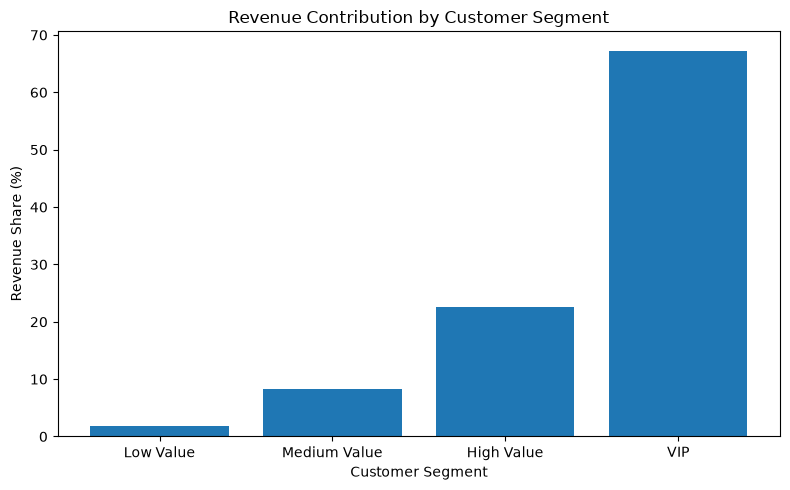

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis.index,
    segment_analysis["revenue_share_%"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Share (%)")
plt.tight_layout()
plt.show()

In [47]:
frequency_analysis = (
    customer_sales.groupby("customer_segment", observed=True)
    .agg(
        customers=("orders", "count"),
        avg_orders=("orders", "mean"),
        total_orders=("orders", "sum"),
        avg_revenue=("revenue", "mean")
    )
)

frequency_analysis

,customers,avg_orders,total_orders,avg_revenue
customer_segment,,,,
Low Value,5705,1.742331,9940,8142.491911
Medium Value,5705,3.137423,17899,35367.918650
High Value,5705,4.838738,27605,97021.874803
VIP,5705,7.809991,44556,288897.859132


In [48]:
state_sales = (
    sales.groupby("delivery_state")
    .agg(
        revenue=("item_revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
)

state_sales.head(10)

,revenue,profit,orders,customers
delivery_state,,,,
Maharashtra,3.427220e+08,27980829.34,14196,3993
Uttar Pradesh,2.663666e+08,21947488.83,10648,3133
Gujarat,2.594968e+08,20599585.95,10379,2916
Karnataka,1.953750e+08,15330594.30,7955,2327
Tamil Nadu,1.852917e+08,14368419.12,7691,2248
Telangana,1.761417e+08,14189895.62,6970,1942
Haryana,1.517778e+08,12601178.78,6205,1720
West Bengal,1.419870e+08,11575503.72,5962,1742
Kerala,1.234332e+08,10710021.86,5068,1540


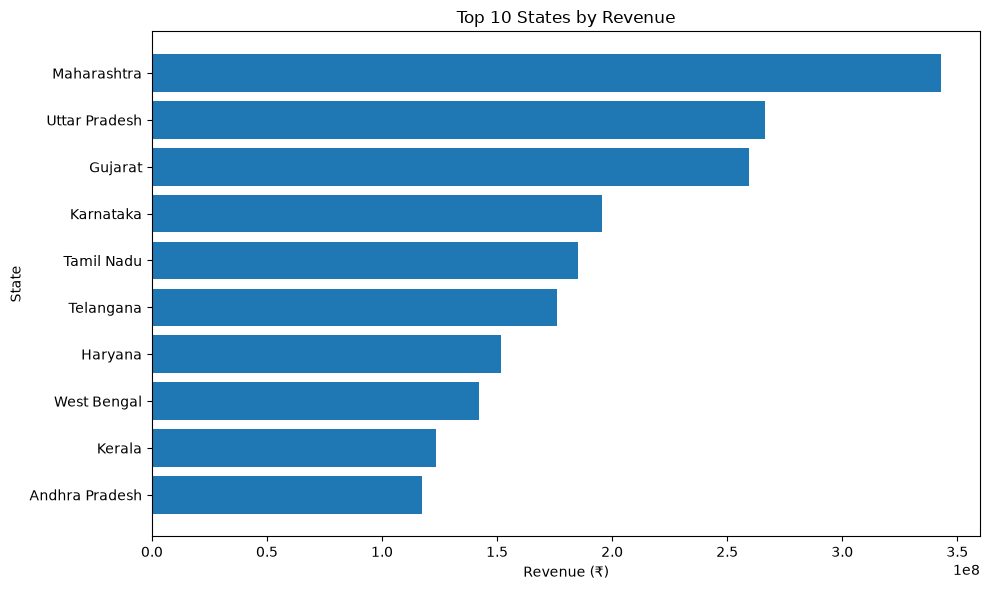

In [49]:
top_states = state_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states.index[::-1],
    top_states["revenue"][::-1]
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [50]:
returns = pd.read_csv("data/returns.csv")

print("Returns shape:", returns.shape)
returns.head()

Returns shape: (12075, 8)


,return_id,order_id,customer_id,product_id,return_date,return_reason,refund_amount,return_status
0,RET100000,ORD1000009,CUST117396,PROD10073,2024-05-28,Changed mind,2094.4,Refund Completed
1,RET100001,ORD1000019,CUST122124,PROD10077,2023-12-30,Product damaged,1040.0,Refund Completed
2,RET100002,ORD1000019,CUST122124,PROD10451,2024-01-06,Wrong product,0.0,Pending
3,RET100003,ORD1000019,CUST122124,PROD10043,2024-01-05,Quality issue,15104.0,Refund Completed
4,RET100004,ORD1000028,CUST101962,PROD10171,2023-06-19,Changed mind,0.0,Pending


In [51]:
returns_sales = returns.merge(
    orders[["order_id", "customer_id", "order_date"]],
    on="order_id",
    how="left"
)

print("Returns:", len(returns_sales))
returns_sales.head()

Returns: 12075


,return_id,order_id,customer_id_x,product_id,return_date,return_reason,refund_amount,return_status,customer_id_y,order_date
0,RET100000,ORD1000009,CUST117396,PROD10073,2024-05-28,Changed mind,2094.4,Refund Completed,CUST117396,2024-05-26
1,RET100001,ORD1000019,CUST122124,PROD10077,2023-12-30,Product damaged,1040.0,Refund Completed,CUST122124,2023-12-27
2,RET100002,ORD1000019,CUST122124,PROD10451,2024-01-06,Wrong product,0.0,Pending,CUST122124,2023-12-27
3,RET100003,ORD1000019,CUST122124,PROD10043,2024-01-05,Quality issue,15104.0,Refund Completed,CUST122124,2023-12-27
4,RET100004,ORD1000028,CUST101962,PROD10171,2023-06-19,Changed mind,0.0,Pending,CUST101962,2023-06-14


In [52]:
returns_sales = returns.merge(
    orders[["order_id", "customer_id", "order_date"]],
    on="order_id",
    how="left"
)

print("Returns:", len(returns_sales))
returns_sales.head()

Returns: 12075


,return_id,order_id,customer_id_x,product_id,return_date,return_reason,refund_amount,return_status,customer_id_y,order_date
0,RET100000,ORD1000009,CUST117396,PROD10073,2024-05-28,Changed mind,2094.4,Refund Completed,CUST117396,2024-05-26
1,RET100001,ORD1000019,CUST122124,PROD10077,2023-12-30,Product damaged,1040.0,Refund Completed,CUST122124,2023-12-27
2,RET100002,ORD1000019,CUST122124,PROD10451,2024-01-06,Wrong product,0.0,Pending,CUST122124,2023-12-27
3,RET100003,ORD1000019,CUST122124,PROD10043,2024-01-05,Quality issue,15104.0,Refund Completed,CUST122124,2023-12-27
4,RET100004,ORD1000028,CUST101962,PROD10171,2023-06-19,Changed mind,0.0,Pending,CUST101962,2023-06-14


In [53]:
return_summary = (
    returns_sales.groupby("return_reason")
    .size()
    .sort_values(ascending=False)
)

return_summary

return_reason
Size issue                 2201
Changed mind               1984
Product damaged            1933
Quality issue              1692
Product not as expected    1442
Wrong product              1394
Late delivery               960
Other                       469
dtype: int64

In [54]:
return_rate = (
    returns_sales["order_id"].nunique()
    / orders["order_id"].nunique()
    * 100
)

print("Overall Return Rate:", round(return_rate, 2), "%")

Overall Return Rate: 9.51 %


In [55]:
status_analysis = (
    orders.groupby("order_status")
    .agg(
        orders=("order_id", "count"),
        revenue=("final_amount", "sum")
    )
    .sort_values("orders", ascending=False)
)

status_analysis

,orders,revenue
order_status,,
Delivered,80679,2.084310e+09
Cancelled,8073,2.026335e+08
Returned,6681,1.698690e+08
Failed,2880,7.181461e+07
Processing,1687,4.396551e+07


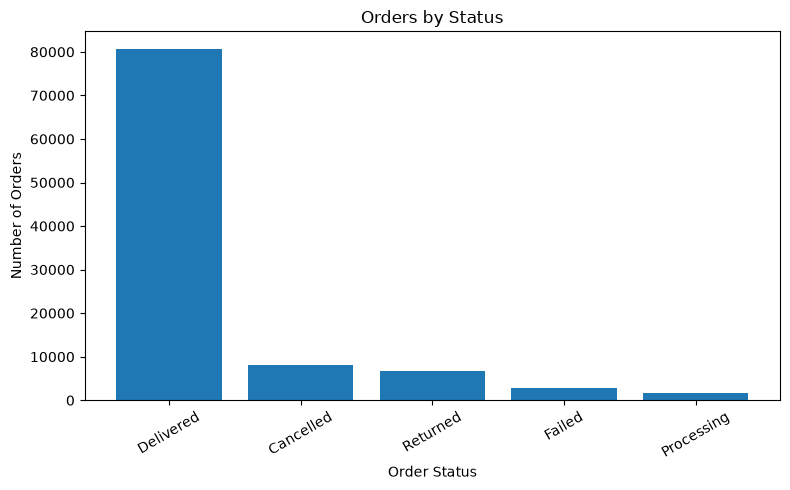

In [56]:
plt.figure(figsize=(8, 5))

plt.bar(
    status_analysis.index,
    status_analysis["orders"]
)

plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [57]:
print("PROJECT KPIs")

print("Revenue: ₹", round(total_revenue, 2))
print("Profit: ₹", round(total_profit, 2))
print("Orders:", total_orders)
print("Customers:", total_customers)
print("Items Sold:", total_items_sold)
print("AOV: ₹", round(average_order_value, 2))

print("\nKEY FINDINGS")

print("Top Category:", category_sales.index[0])
print("Top Product:", product_sales.index[0])
print("Loss-making Products:", len(loss_making_products))
print("Total Product Loss: ₹", round(loss_making_products["profit"].sum(), 2))

print("Top State:", state_sales.index[0])
print("Return Rate:", round(return_rate, 2), "%")

PROJECT KPIs
Revenue: ₹ 2449898974.35
Profit: ₹ 197294347.02
Orders: 100000
Customers: 22820
Items Sold: 585640
AOV: ₹ 24498.99

KEY FINDINGS
Top Category: Electronics
Top Product: ('PROD10246', 'Chaudhry, Advanced Smartwatche')
Loss-making Products: 33
Total Product Loss: ₹ -13583296.68
Top State: Maharashtra
Return Rate: 9.51 %


In [58]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Unique Customers",
        "Items Sold",
        "Average Order Value",
        "Return Rate",
        "Loss-Making Products",
        "Total Product Loss"
    ],
    "Value": [
        total_revenue,
        total_profit,
        total_orders,
        total_customers,
        total_items_sold,
        average_order_value,
        return_rate,
        len(loss_making_products),
        loss_making_products["profit"].sum()
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,2.449899e+09
1,Total Profit,1.972943e+08
2,Total Orders,1.000000e+05
3,Unique Customers,2.282000e+04
4,Items Sold,5.856400e+05
5,Average Order Value,2.449899e+04
6,Return Rate,9.510000e+00
7,Loss-Making Products,3.300000e+01
8,Total Product Loss,-1.358330e+07
